# Differentialgleichungen II: Lineare DGL, Resonanz und Euler-DGL

Begleitendes Notebook zu *Angew.Mathe.1Differentialgleichungen Teil 2* (Abschnitte 1.5 bis 1.8): lineare Gleichungen erster und zweiter Ordnung, charakteristische Polynome, Resonanz und Euler-Differentialgleichungen.

**Voraussetzungen:** `numpy`, `sympy`, `matplotlib`  
**Arbeitsweise:** Zellen der Reihe nach ausführen und die Kontrollausgaben prüfen.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/karkessler/dhbw-mathe3/blob/main/notebooks/differentialgleichungen/02_lineare_dgl_resonanz_euler.ipynb)

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

## 1. Lineare DGL erster Ordnung

Eine lineare Differentialgleichung erster Ordnung hat die Form $y'+p(x)y=q(x)$. Hier beschreibt $2y$ den homogenen Anteil, während $x^2$ als äußere Anregung wirkt. Die allgemeine Lösung setzt sich aus einer Lösung der homogenen Gleichung und einer speziellen, partikulären Lösung zusammen.

Die Codezelle bestimmt die Lösung mit `dsolve`. Anschließend wird die rechte Seite abgeleitet und wieder in $y'+2y-x^2$ eingesetzt. Das Residuum muss null sein; damit wird nicht nur die Ausgabe des Programms angezeigt, sondern die Differentialgleichung direkt überprüft.

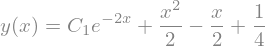

Residuum = 0


In [2]:
x = sp.symbols('x', real=True)
yfun = sp.Function('y')
eq1 = sp.Eq(sp.diff(yfun(x), x) + 2*yfun(x), x**2)
sol1 = sp.dsolve(eq1)
display(sol1)
rhs1 = sol1.rhs
print('Residuum =', sp.simplify(sp.diff(rhs1, x) + 2*rhs1 - x**2))

### 1.1 Struktur $y = y_h + y_p$ im Richtungsfeld

Die allgemeine Lösung ist $y = C\,e^{-2x} + \tfrac12x^2 - \tfrac12x + \tfrac14$. Der Term $C\,e^{-2x}$ löst die zugehörige homogene Gleichung und enthält den Einfluss der Anfangsbedingung. Der Rest ist eine partikuläre Lösung $y_p$, die allein durch die rechte Seite $x^2$ bestimmt wird.

Weil $e^{-2x}$ für wachsende $x$ gegen null geht, klingt der homogene Anteil ab. Die verschiedenen Kurven im Richtungsfeld unterscheiden sich zunächst durch ihre Konstante $C$, nähern sich aber alle derselben Kurve $y_p$. Das Richtungsfeld macht sichtbar, dass jede dieser Kurven die lokale Steigung der Differentialgleichung einhält.

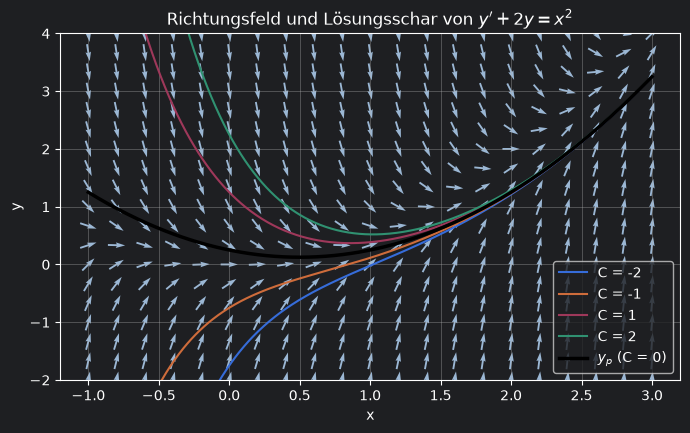

In [3]:
y_p1 = x**2/2 - x/2 + sp.Rational(1, 4)
assert sp.simplify(sp.diff(y_p1, x) + 2*y_p1 - x**2) == 0
f_p1 = sp.lambdify(x, y_p1, 'numpy')

X, Y = np.meshgrid(np.linspace(-1, 3, 21), np.linspace(-2, 4, 19))
V = X**2 - 2*Y
N = np.sqrt(1 + V**2)
plt.quiver(X, Y, 1/N, V/N, color='#9bb7d4', pivot='mid')
xx = np.linspace(-1, 3, 400)
for C in (-2, -1, 1, 2):
    plt.plot(xx, C*np.exp(-2*xx) + f_p1(xx), linewidth=1.5, label=f'C = {C}')
plt.plot(xx, f_p1(xx), color='black', linewidth=2.5, label='$y_p$ (C = 0)')
plt.ylim(-2, 4); plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title("Richtungsfeld und Lösungsschar von $y'+2y=x^2$"); plt.show()

## 2. Charakteristisches Polynom

Bei linearen homogenen Differentialgleichungen mit konstanten Koeffizienten führt der Exponentialansatz $y=e^{\lambda x}$ auf das charakteristische Polynom. Denn jede Ableitung von $e^{\lambda x}$ liefert wieder einen Faktor $\lambda$. Für $y''+3y'+2y=0$ entsteht $P(\lambda)=\lambda^2+3\lambda+2$.

Die Nullstellen $\lambda_1=-1$ und $\lambda_2=-2$ sind verschieden; deshalb bilden $e^{-x}$ und $e^{-2x}$ zwei unabhängige Lösungen. Ihre Linearkombination enthält zwei frei wählbare Konstanten und kann somit zwei Anfangsbedingungen erfüllen. Beide Exponentialanteile klingen ab, daher ist die Nulllösung asymptotisch stabil.

In [4]:
lam = sp.symbols('lambda')
poly = lam**2 + 3*lam + 2
roots = sp.solve(poly, lam)
print('p(lambda) =', sp.factor(poly))
print('Nullstellen:', roots)
C1, C2 = sp.symbols('C1 C2')
y_h = C1*sp.exp(-x) + C2*sp.exp(-2*x)
assert sp.simplify(sp.diff(y_h,x,2)+3*sp.diff(y_h,x)+2*y_h) == 0

p(lambda) = (lambda + 1)*(lambda + 2)
Nullstellen: [-2, -1]


### 2.1 Die drei Fälle aus Satz 1.7.4

Für $y''+ay'+by=0$ entscheidet die Diskriminante $D=a^2-4b$ über die Nullstellen des charakteristischen Polynoms und damit über die Form der Lösung. Bei $D>0$ entstehen zwei reelle Exponentialanteile, bei $D=0$ ein Exponentialterm mit zusätzlichem Faktor $x$, und bei $D<0$ eine Kombination aus Sinus und Kosinus mit Exponentialhülle.

Die Grafik löst je ein Beispiel für alle drei Fälle mit denselben Anfangswerten $y(0)=1$ und $y'(0)=0$. So lässt sich der qualitative Unterschied direkt vergleichen: reine Abklingvorgänge bei reellen Nullstellen und gedämpfte Schwingungen bei komplexen Nullstellen.

a = 4, b = 1:  D = 12,  Nullstellen [-2 - sqrt(3), -2 + sqrt(3)]
a = 2, b = 1:  D = 0,  Nullstellen [-1]
a = 1, b = 17/4:  D = -16,  Nullstellen [-1/2 - 2*I, -1/2 + 2*I]


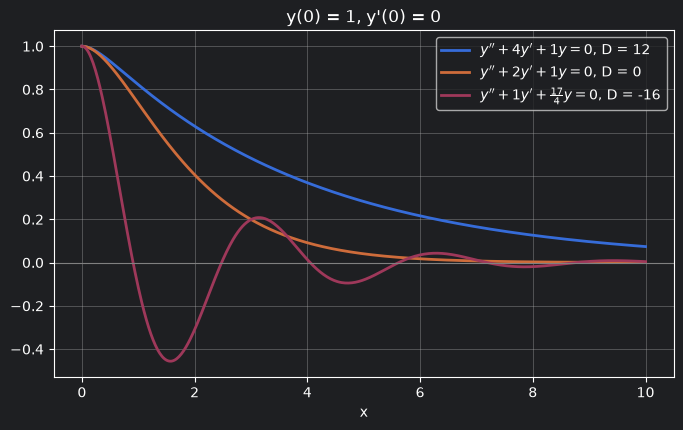

In [5]:
beispiele = [(4, 1), (2, 1), (1, sp.Rational(17, 4))]
grid = np.linspace(0, 10, 500)
for a, b in beispiele:
    D = a**2 - 4*b
    gl = sp.Eq(sp.diff(yfun(x), x, 2) + a*sp.diff(yfun(x), x) + b*yfun(x), 0)
    loes = sp.dsolve(gl, ics={yfun(0): 1, sp.diff(yfun(x), x).subs(x, 0): 0})
    nst = sp.solve(lam**2 + a*lam + b, lam)
    print(f'a = {a}, b = {b}:  D = {D},  Nullstellen {nst}')
    plt.plot(grid, sp.lambdify(x, loes.rhs, 'numpy')(grid), linewidth=2,
             label=f"$y''+{a}y'+{sp.latex(b)}y=0$, D = {D}")
plt.axhline(0, color='gray', linewidth=0.8)
plt.xlabel('x'); plt.legend(); plt.title("y(0) = 1, y'(0) = 0"); plt.show()

### 2.2 Komplexe Nullstellen und Eulersche Formel

Für $D<0$ sind die Nullstellen $\lambda=\alpha\pm i\beta$. Die Euler-Formel schreibt die komplexe Exponentialfunktion als $e^{(\alpha+i\beta)x}=e^{\alpha x}(\cos\beta x+i\sin\beta x)$. Weil die Differentialgleichung reelle Koeffizienten besitzt, sind Real- und Imaginärteil selbst reelle Lösungen: $y_1=e^{\alpha x}\cos(\beta x)$ und $y_2=e^{\alpha x}\sin(\beta x)$.

Der linke Plot interpretiert die komplexe Lösung als Zeiger in der komplexen Ebene. Der Winkel wächst mit der Kreisfrequenz $\beta$, während $e^{\alpha x}$ seinen Abstand vom Ursprung bestimmt. Rechts wird der Realteil gezeigt: Er schwingt zwischen den Hüllkurven $\pm e^{\alpha x}$. Für $\alpha<0$ wird die Spirale und damit die Schwingung gedämpft.

y1 und y2 lösen y'' + y' + 17/4 y = 0


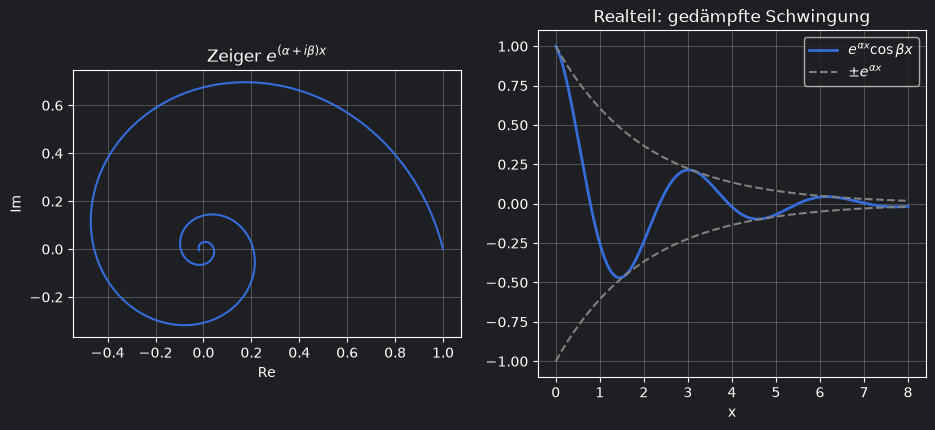

In [6]:
al, be = sp.Rational(-1, 2), 2
y1 = sp.exp(al*x)*sp.cos(be*x)
y2 = sp.exp(al*x)*sp.sin(be*x)
for yk in (y1, y2):
    assert sp.simplify(sp.diff(yk, x, 2) + sp.diff(yk, x) + sp.Rational(17, 4)*yk) == 0
print("y1 und y2 lösen y'' + y' + 17/4 y = 0")

xs = np.linspace(0, 8, 800)
z = np.exp((float(al) + 1j*be)*xs)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(z.real, z.imag); ax1.set_aspect('equal')
ax1.set_xlabel('Re'); ax1.set_ylabel('Im'); ax1.set_title(r'Zeiger $e^{(\alpha+i\beta)x}$')
ax2.plot(xs, z.real, linewidth=2, label=r'$e^{\alpha x}\cos\beta x$')
ax2.plot(xs, np.exp(float(al)*xs), '--', color='gray', label=r'$\pm e^{\alpha x}$')
ax2.plot(xs, -np.exp(float(al)*xs), '--', color='gray')
ax2.set_xlabel('x'); ax2.legend(); ax2.set_title('Realteil: gedämpfte Schwingung')
plt.show()

## 3. Inhomogene DGL zweiter Ordnung

Bei einer inhomogenen Gleichung zweiter Ordnung entsteht die Lösung ebenfalls als Summe $y=y_h+y_p$. Der homogene Teil beschreibt den von den Anfangswerten abhängigen Übergangsvorgang; der partikuläre Teil ist die dauerhafte Antwort auf die Anregung $\sin x$.

Die Anfangswerte $y(0)=0$ und $y'(0)=0$ wählen eine konkrete Lösung aus der Lösungsfamilie. Im Plot wird sie zusammen mit der sinusförmigen Anregung dargestellt. Da die homogenen Eigenwerte negativ sind, klingen die freien Anteile ab und langfristig bleibt eine gedämpft-phasenverschobene Antwort mit derselben Frequenz wie die Anregung.

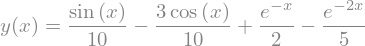

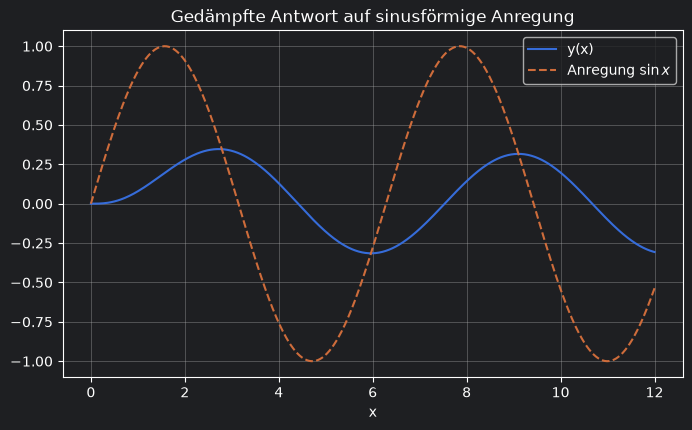

In [7]:
eq2 = sp.Eq(sp.diff(yfun(x),x,2)+3*sp.diff(yfun(x),x)+2*yfun(x), sp.sin(x))
sol2 = sp.dsolve(eq2, ics={yfun(0): 0, sp.diff(yfun(x),x).subs(x,0): 0})
display(sol2)
f2 = sp.lambdify(x, sol2.rhs, 'numpy')
grid = np.linspace(0, 12, 500)
plt.plot(grid, f2(grid), label='y(x)')
plt.plot(grid, np.sin(grid), '--', label=r'Anregung $\sin x$')
plt.xlabel('x'); plt.legend(); plt.title('Gedämpfte Antwort auf sinusförmige Anregung'); plt.show()

### 3.1 Ansatz von Hand mit Koeffizientenvergleich

`dsolve` liefert das Ergebnis, aber nicht den Rechenweg. Weil Ableitungen von Sinus und Kosinus wieder Linearkombinationen von Sinus und Kosinus sind, wählen wir den Ansatz $y_p=A\cos x+B\sin x$. Nach dem Einsetzen müssen die Koeffizienten vor $\cos x$ und $\sin x$ jeweils mit der rechten Seite übereinstimmen.

Es liegt kein Resonanzfall vor, weil die Störzahl $i$ keine Nullstelle des charakteristischen Polynoms ist. Deshalb genügt der einfache Ansatz ohne zusätzlichen Faktor $x$. Die Codezelle stellt die beiden Gleichungen für $A$ und $B$ auf, löst sie und überprüft das Ergebnis durch Einsetzen.

Lösung: {A: -3/10, B: 1/10}


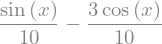

In [8]:
A_, B_ = sp.symbols('A B')
ansatz = A_*sp.cos(x) + B_*sp.sin(x)
rest = sp.expand(sp.diff(ansatz, x, 2) + 3*sp.diff(ansatz, x) + 2*ansatz - sp.sin(x))
gleichungen = [sp.Eq(rest.coeff(sp.cos(x)), 0), sp.Eq(rest.coeff(sp.sin(x)), 0)]
display(gleichungen)
koeff = sp.solve(gleichungen, [A_, B_])
y_p2 = ansatz.subs(koeff)
print('Lösung:', koeff)
display(y_p2)
assert sp.simplify(sp.diff(y_p2, x, 2) + 3*sp.diff(y_p2, x) + 2*y_p2 - sp.sin(x)) == 0

### 3.2 Einschwingvorgang

Die Lösung aus Abschnitt 3 zerfällt in $y=y_h+y_p$. Der homogene Anteil erfüllt die Gleichung ohne rechte Seite und sorgt dafür, dass die Anfangswerte eingehalten werden. Der partikuläre Anteil ist die stationäre Antwort auf die periodische Störung.

Im markierten Einschwingbereich ist der homogene Anteil noch deutlich sichtbar. Da er nur aus $e^{-x}$ und $e^{-2x}$ besteht, verschwindet er mit der Zeit. Anschließend stimmt die Gesamtlösung praktisch mit $y_p$ überein: Das System hat seinen dauerhaften, durch die Anregung erzwungenen Zustand erreicht.

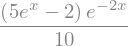

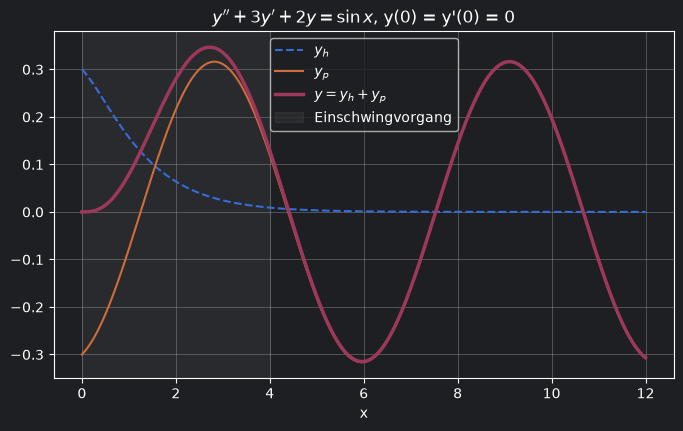

In [9]:
y_h2 = sp.simplify(sol2.rhs - y_p2)
display(y_h2)
g = np.linspace(0, 12, 500)
plt.plot(g, sp.lambdify(x, y_h2, 'numpy')(g), '--', label='$y_h$')
plt.plot(g, sp.lambdify(x, y_p2, 'numpy')(g), label='$y_p$')
plt.plot(g, f2(g), linewidth=2.5, label='$y = y_h + y_p$')
plt.axvspan(0, 4, color='gray', alpha=0.12, label='Einschwingvorgang')
plt.xlabel('x'); plt.legend(); plt.title("$y''+3y'+2y=\\sin x$, y(0) = y'(0) = 0"); plt.show()

## 4. Resonanz beim Ansatz

Für $(D+1)^2y=e^{-x}$ ist $-1$ bereits eine doppelte Nullstelle. Der einfache Ansatz $Ae^{-x}$ läge damit bereits im Lösungsraum der homogenen Gleichung und kann keine neue partikuläre Lösung liefern. Erst der Faktor $x^2$ macht den Ansatz linear unabhängig: $y_p=Ax^2e^{-x}$.


*Schreibweise:* $(D+1)^2y$ steht für $y''+2y'+y$, $D$ ist hier der Ableitungsoperator $\tfrac{d}{dx}$. Im Skript lautet dieselbe Aussage: $\lambda=-1$ ist doppelte Nullstelle von $P(\lambda)=\lambda^2+2\lambda+1$. Nicht zu verwechseln mit der Diskriminante $D=a^2-4b$.

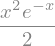

Residuum = 0


In [10]:
y_p = sp.Rational(1,2) * x**2 * sp.exp(-x)
res = sp.simplify(sp.diff(y_p,x,2)+2*sp.diff(y_p,x)+y_p-sp.exp(-x))
display(y_p)
print('Residuum =', res)
assert res == 0

### 4.1 Resonanztest über die Störzahl

Hat die rechte Seite die Form $e^{kx}(\ldots\cos\omega x+\ldots\sin\omega x)$, heißt $s=k+i\omega$ Störzahl. Sie fasst exponentielle Änderung und Kreisfrequenz der Anregung in einer komplexen Zahl zusammen. Ist $s$ keine Nullstelle von $P$, genügt der Standardansatz.

Ist $s$ dagegen eine $m$-fache Nullstelle von $P$, fällt der Ansatz mit einer homogenen Lösung zusammen. Um eine unabhängige partikuläre Lösung zu erhalten, wird er mit $x^m$ multipliziert. Die Tabelle bestimmt diese Vielfachheit automatisch und zeigt den nötigen Faktor für mehrere typische Störfunktionen.

In [11]:
def resonanz(P, s):
    return sp.roots(sp.Poly(P, lam)).get(sp.nsimplify(s), 0)

faelle = [
    (lam**2 + 2*lam + 1, 'e^{-x}', -1),
    (lam**2 + 2*lam + 1, 'e^{x}', 1),
    (lam**2 + 2*lam + 1, 'sin x', sp.I),
    (lam**2 + 1, 'sin x', sp.I),
    (lam**2 + 2*lam + 2, 'e^{-x} sin x', -1 + sp.I),
]
for P, r, s in faelle:
    m = resonanz(P, s)
    print(f'P = {str(P):18s} r = {r:13s} s = {str(s):7s} m = {m}  ->',
          f'Ansatz mal x^{m}' if m else 'kein Resonanzfall')

P = lambda**2 + 2*lambda + 1 r = e^{-x}        s = -1      m = 2  -> Ansatz mal x^2
P = lambda**2 + 2*lambda + 1 r = e^{x}         s = 1       m = 0  -> kein Resonanzfall
P = lambda**2 + 2*lambda + 1 r = sin x         s = I       m = 0  -> kein Resonanzfall
P = lambda**2 + 1      r = sin x         s = I       m = 1  -> Ansatz mal x^1
P = lambda**2 + 2*lambda + 2 r = e^{-x} sin x  s = -1 + I  m = 1  -> Ansatz mal x^1


### 4.2 Resonanz ohne Dämpfung

Für $y''+y=\sin(\omega x)$ mit $y(0)=y'(0)=0$ hat das ungestörte System die Eigenfrequenz $1$. Bei $\omega=2$ liegt keine Resonanz vor und die Lösung bleibt beschränkt. Bei $\omega=1$ stimmt die Anregungsfrequenz dagegen genau mit der Eigenfrequenz überein; die zugeführte Energie addiert sich fortlaufend.

Mathematisch ist $s=i$ dann eine Nullstelle von $P(\lambda)=\lambda^2+1$. Der Resonanzansatz enthält einen Faktor $x$, und die Amplitude wächst linear. Im Plot liegt die resonante Lösung deshalb zwischen den Geraden $\pm x/2$, während die nicht resonante Schwingung begrenzt bleibt.

omega = 2: 2*sin(x)/3 - sin(2*x)/3
omega = 1: -x*cos(x)/2 + sin(x)/2


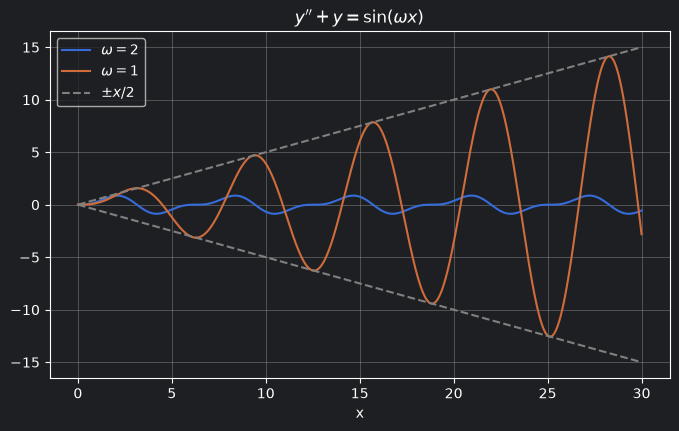

In [12]:
g = np.linspace(0, 30, 1500)
for w in (2, 1):
    gl = sp.Eq(sp.diff(yfun(x), x, 2) + yfun(x), sp.sin(w*x))
    loes = sp.dsolve(gl, ics={yfun(0): 0, sp.diff(yfun(x), x).subs(x, 0): 0})
    print(f'omega = {w}:', loes.rhs)
    plt.plot(g, sp.lambdify(x, loes.rhs, 'numpy')(g), label=f'$\\omega = {w}$')
plt.plot(g, g/2, '--', color='gray'); plt.plot(g, -g/2, '--', color='gray', label='$\\pm x/2$')
plt.xlabel('x'); plt.legend(); plt.title("$y''+y=\\sin(\\omega x)$"); plt.show()

## 5. Euler-Differentialgleichung

Bei einer Euler-Differentialgleichung tragen die Ableitungen passende Potenzen von $x$: $x^2y''+3xy'+y=0$. Daher ersetzt der Potenzansatz $y=x^\lambda$ den sonst üblichen Exponentialansatz. Nach Einsetzen entsteht das algebraische charakteristische Polynom $\lambda^2+2\lambda+1=(\lambda+1)^2$.

Die doppelte Nullstelle $\lambda=-1$ liefert zwei unabhängige Lösungen $x^{-1}$ und $x^{-1}\ln x$. Ihre Linearkombination ist für $x>0$ definiert. Der Plot zeigt, wie die Konstanten $C_1$ und $C_2$ die Lösungsform verändern und warum die Stelle $x=0$ wegen der Gleichung und des Logarithmus ausgeschlossen bleibt.

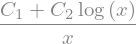

Residuum = 0


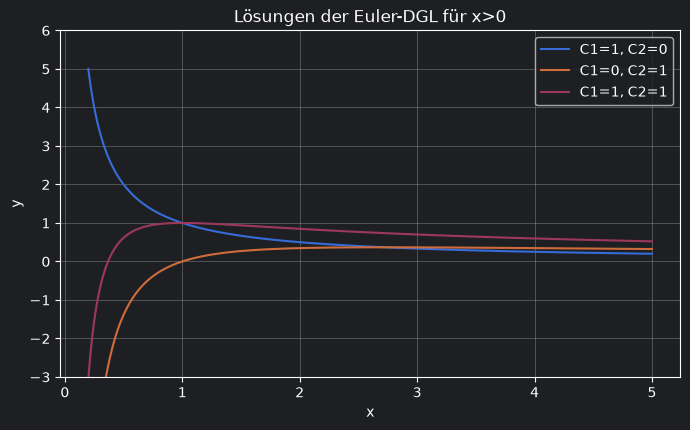

In [13]:
C1, C2 = sp.symbols('C1 C2')
y_e = (C1 + C2*sp.log(x))/x
res_e = sp.simplify(x**2*sp.diff(y_e,x,2)+3*x*sp.diff(y_e,x)+y_e)
display(y_e)
print('Residuum =', res_e)
assert res_e == 0

xx = np.linspace(0.2, 5, 400)
for c1, c2 in ((1,0), (0,1), (1,1)):
    yy = (c1 + c2*np.log(xx))/xx
    plt.plot(xx, yy, label=f'C1={c1}, C2={c2}')
plt.xlabel('x'); plt.ylabel('y'); plt.ylim(-3,6); plt.legend();
plt.title('Lösungen der Euler-DGL für x>0'); plt.show()

### 5.1 Euler-DGL für $x<0$

Die Herleitung mit $x^\lambda$ und $\ln x$ gilt zunächst nur für $x>0$. Für die negative Halbachse setzt man $z(x)=y(-x)$ und erhält wieder eine Euler-Differentialgleichung auf $x>0$. Dadurch erscheint im Ergebnis der Betrag $|x|$.

Auf jedem der beiden Intervalle $(-\infty,0)$ und $(0,\infty)$ gilt dieselbe Lösungsform $y=\dfrac{C_1+C_2\ln|x|}{|x|}$. Die beiden Seiten können jedoch nicht über $x=0$ zu einer klassischen Lösung verbunden werden, weil dort sowohl die Differentialgleichung als auch die dargestellte Funktion singulär sind.

Residuum für x < 0 = 0


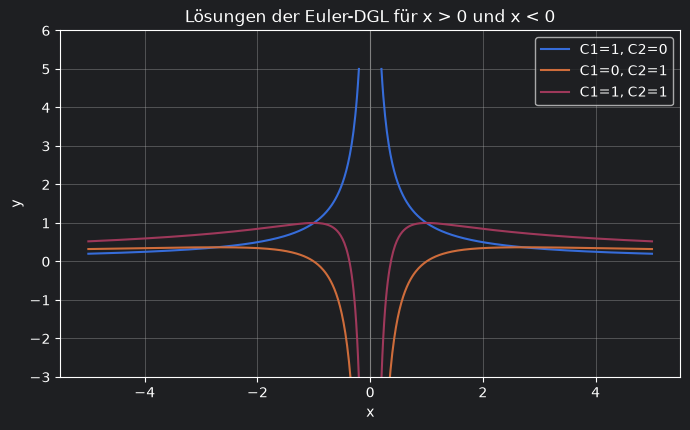

In [14]:
xn = sp.symbols('x', negative=True)
y_neg = (C1 + C2*sp.log(-xn))/(-xn)
res_neg = sp.simplify(xn**2*sp.diff(y_neg, xn, 2) + 3*xn*sp.diff(y_neg, xn) + y_neg)
print('Residuum für x < 0 =', res_neg)
assert res_neg == 0

for c1, c2 in ((1, 0), (0, 1), (1, 1)):
    for xx in (np.linspace(0.2, 5, 300), np.linspace(-5, -0.2, 300)):
        plt.plot(xx, (c1 + c2*np.log(np.abs(xx)))/np.abs(xx), color=f'C{c1 + 2*c2 - 1}')
    plt.plot([], [], color=f'C{c1 + 2*c2 - 1}', label=f'C1={c1}, C2={c2}')
plt.axvline(0, color='gray', linewidth=0.8)
plt.ylim(-3, 6); plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title('Lösungen der Euler-DGL für x > 0 und x < 0'); plt.show()